### Preprocessing ###

In [ ]:
# This allows me to get data from FRED
my_api_key = 'YOUR_API_KEY_HERE'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
import tensorflow as tf
import random

In [3]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
fred = Fred(api_key=my_api_key)

gdi = fred.get_series_first_release('A261RX1Q020SBEA')
#print(gdi) #qly 47

gdp = fred.get_series_first_release('GDPC1')
#print(gdp) #qly 47

#gdp_gni_avg = fred.get_series_first_release('LB0000091Q020SBEA')
#print(gdp_gni_avg) #qly 47

emp = fred.get_series_first_release('CE16OV')
#print(emp) #mly 47

indpro = fred.get_series_first_release('INDPRO')
#print(indpro) #mly 1919

payems = fred.get_series_first_release('PAYEMS')
#print(payems) #mly 39

pilt = fred.get_series_first_release('W875RX1')
#print(pilt) #mly 59

pce = fred.get_series_first_release('PCEC96')
#print(pce) #mly 59

tm_sales = fred.get_series_first_release('CMRMTSPL')
#print(tm_sales) #mly 67


In [6]:
recession = pd.read_csv('recessions.csv')
#print(recession)

In [7]:
emp_q = emp.resample('QS').last()
indpro_q = indpro.resample('QS').last()
payems_q = payems.resample('QS').last()
pilt_q = pilt.resample('QS').last()
pce_q = pce.resample('QS').last()
tm_sales_q = tm_sales.resample('QS').last()

In [8]:
features = [gdp, gdi, emp_q, indpro_q, payems_q, pilt_q, pce_q, tm_sales_q]
df = pd.concat(features, axis=1)
df.columns = [
    'gdp',
    'gdi',
    'emp',
    'indpro',
    'payems',
    'pilt',
    'pce',
    'tm_sales'
]
print(df)

                  gdp        gdi       emp    indpro    payems     pilt  \
date                                                                      
1919-01-01        NaN        NaN       NaN      77.0       NaN      NaN   
1919-04-01        NaN        NaN       NaN      83.0       NaN      NaN   
1919-07-01        NaN        NaN       NaN      87.0       NaN      NaN   
1919-10-01        NaN        NaN       NaN      85.0       NaN      NaN   
1920-01-01        NaN        NaN       NaN      94.0       NaN      NaN   
...               ...        ...       ...       ...       ...      ...   
2025-01-01  23526.085  23428.858  163508.0  103.8892  159398.0  16500.4   
2025-04-01  23685.287  23727.399  163366.0  104.0071  159724.0  16496.0   
2025-07-01  24024.957  23724.735  163645.0  101.4279  159626.0  16742.6   
2025-10-01   24111.83        NaN  163992.0   102.325  159526.0  16644.2   
2026-01-01        NaN        NaN  162848.0   102.551  158637.0  16740.9   

                pce   tm

In [9]:
df.dropna(inplace=True)
print(df)

                  gdp        gdi       emp    indpro    payems     pilt  \
date                                                                      
1967-01-01     2662.1     3872.1   73747.0     156.4   65486.0   2857.3   
1967-04-01     2673.7     3892.8   74147.0     155.2   65565.0   2874.7   
1967-07-01     2704.9     3933.5   74625.0     156.3   66100.0   2903.2   
1967-10-01     2720.6     3972.5   75681.0     161.6   67128.0   2946.0   
1968-01-01     2758.0     4032.7   75802.0     162.1   67855.0   2986.6   
...               ...        ...       ...       ...       ...      ...   
2024-07-01  23386.248  23195.268  161864.0  102.6418  159105.0  16426.8   
2024-10-01  23530.909   23400.13  161661.0  103.1942  159536.0  16457.8   
2025-01-01  23526.085  23428.858  163508.0  103.8892  159398.0  16500.4   
2025-04-01  23685.287  23727.399  163366.0  104.0071  159724.0  16496.0   
2025-07-01  24024.957  23724.735  163645.0  101.4279  159626.0  16742.6   

                pce    t

In [10]:
recession['date'] = pd.to_datetime(recession['quarter start'])
recession.set_index('date', inplace=True)
df = df.join(recession['recession'], how='left')
print(df)

                  gdp        gdi       emp    indpro    payems     pilt  \
date                                                                      
1967-01-01     2662.1     3872.1   73747.0     156.4   65486.0   2857.3   
1967-04-01     2673.7     3892.8   74147.0     155.2   65565.0   2874.7   
1967-07-01     2704.9     3933.5   74625.0     156.3   66100.0   2903.2   
1967-10-01     2720.6     3972.5   75681.0     161.6   67128.0   2946.0   
1968-01-01     2758.0     4032.7   75802.0     162.1   67855.0   2986.6   
...               ...        ...       ...       ...       ...      ...   
2024-07-01  23386.248  23195.268  161864.0  102.6418  159105.0  16426.8   
2024-10-01  23530.909   23400.13  161661.0  103.1942  159536.0  16457.8   
2025-01-01  23526.085  23428.858  163508.0  103.8892  159398.0  16500.4   
2025-04-01  23685.287  23727.399  163366.0  104.0071  159724.0  16496.0   
2025-07-01  24024.957  23724.735  163645.0  101.4279  159626.0  16742.6   

                pce    t

In [11]:
#df.to_csv('df.csv')

In [12]:
# Convert to % changes
df['gdp'] = df['gdp'].pct_change()
df['gdi'] = df['gdi'].pct_change()
df['emp'] = df['emp'].pct_change()
df['indpro'] = df['indpro'].pct_change()
df['payems'] = df['payems'].pct_change()
df['pilt'] = df['pilt'].pct_change()
df['pce'] = df['pce'].pct_change()
df['tm_sales'] = df['tm_sales'].pct_change()
df.dropna(inplace=True)

In [13]:
print(df.isna().sum())

gdp          0
gdi          0
emp          0
indpro       0
payems       0
pilt         0
pce          0
tm_sales     0
recession    0
dtype: int64


In [ ]:
set_size = 235*0.7
# the training set will be 70% of the data

print(df.index[int(set_size)])
# Close enough to 2008, which is a nice cutoff

cutoff = pd.to_datetime('2008-01-01')

2008-04-01 00:00:00


In [15]:
x = df.drop('recession', axis=1)
y = df['recession']

x_train = x[x.index < cutoff]
x_test = x[x.index >= cutoff]
y_train = y[y.index < cutoff]
y_test = y[y.index >= cutoff]

print(x_train)
print(x_test)

print(y_train)
print(y_test)

                 gdp       gdi       emp    indpro    payems      pilt  \
date                                                                     
1967-04-01  0.004357  0.005346  0.005424 -0.007673  0.001206  0.006090   
1967-07-01  0.011669  0.010455  0.006447  0.007088  0.008160  0.009914   
1967-10-01  0.005804  0.009915  0.014151  0.033909  0.015552  0.014742   
1968-01-01  0.013747  0.015154  0.001599  0.003094  0.010830  0.013781   
1968-04-01  0.016026  0.015002  0.003245  0.014189  0.000118  0.013862   
...              ...       ...       ...       ...       ...       ...   
2006-10-01  0.009508  0.006546  0.007428 -0.006109  0.004432  0.015038   
2007-01-01  0.000650 -0.006503  0.002248  0.000392  0.010337  0.004608   
2007-04-01 -0.003567  0.001362 -0.000779  0.007857  0.003023  0.001266   
2007-07-01  0.010671 -0.003235  0.000801  0.008702  0.001644  0.004498   
2007-10-01  0.004015  0.003601 -0.000315 -0.003408  0.001663 -0.004045   

                 pce  tm_sales  
date

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), index=x_train.index, columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), index=x_test.index, columns=x_test.columns)

### The Baseline (Chauvet and Piger 2008)

Note that I used some heavy AI use to translate their paper into code to be workable for my paper.

In [17]:
import statsmodels.api as sm
from sklearn.decomposition import PCA

In [18]:
tickers_2008 = ['indpro', 'payems', 'pilt', 'tm_sales']

x_2008 = df[tickers_2008].dropna()
print(x_2008.tail())

              indpro    payems      pilt  tm_sales
date                                              
2024-07-01 -0.013004  0.002944  0.032068  0.010897
2024-10-01  0.005382  0.002709  0.001887  0.010257
2025-01-01  0.006735 -0.000865  0.002588  0.012934
2025-04-01  0.001135  0.002045 -0.000267 -0.005721
2025-07-01 -0.024798 -0.000614  0.014949 -0.009557


In [19]:
pca = PCA(n_components=1, random_state=42)
factor = pca.fit_transform(x_2008)

factor_df = pd.DataFrame(factor, index=x_2008.index, columns=['Component'])

ms = sm.tsa.MarkovRegression(factor_df['Component'],
                             k_regimes=2,
                             trend='c',
                             switching_variance=True)
ms_results = ms.fit(disp=False)
regime_probs = ms_results.smoothed_marginal_probabilities
print(ms_results.summary())

                        Markov Switching Model Results                        
Dep. Variable:              Component   No. Observations:                  234
Model:               MarkovRegression   Log Likelihood                 546.628
Date:                Wed, 08 Apr 2026   AIC                          -1081.256
Time:                        13:34:48   BIC                          -1060.524
Sample:                    04-01-1967   HQIC                         -1072.896
                         - 07-01-2025                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.001      7.044      0.000       0.006       0.010
sigma2         0.0002   2.87e-05      7.045      0.0

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

In [21]:
# 1 is the recession regime (higher mean and variance as per the paper)

y_pred_ms = regime_probs[1]

y_pred_ms_classes_all = (y_pred_ms > 0.5).astype(int)

s = pd.Series(y_pred_ms_classes_all, index=x_2008.index)

y_pred_ms_classes = s.loc[y_test.index]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ms_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ms_classes))


Confusion Matrix:
[[59  3]
 [ 4  5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94        62
           1       0.62      0.56      0.59         9

    accuracy                           0.90        71
   macro avg       0.78      0.75      0.77        71
weighted avg       0.90      0.90      0.90        71



### Model 0: Null Model

In [22]:
y_pred_null = np.zeros(len(y_test))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_null))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_null))


Confusion Matrix:
[[62  0]
 [ 9  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        62
           1       0.00      0.00      0.00         9

    accuracy                           0.87        71
   macro avg       0.44      0.50      0.47        71
weighted avg       0.76      0.87      0.81        71



### Model 1: Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# using 10-fold CV
cv = TimeSeriesSplit(n_splits=10)
c_grid = [0.001, 0.01, 0.1, 1, 10]

#### No penalty

In [24]:
logreg_none = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42), 
                           param_grid={
                               'C':c_grid,
                               'penalty':[None],
                               'solver':['saga']},
                           cv=cv,
                           scoring='f1',
                           n_jobs=-1)
logreg_none.fit(x_train_scaled, y_train)
y_pred_log = logreg_none.predict(x_test_scaled)

print("Best Parameters:", logreg_none.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Best Parameters: LogisticRegression(C=0.001, class_weight='balanced', penalty=None,
                   random_state=42, solver='saga')

Confusion Matrix:
[[50 12]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        62
           1       0.37      0.78      0.50         9

    accuracy                           0.80        71
   macro avg       0.66      0.79      0.69        71
weighted avg       0.89      0.80      0.83        71



#### Ridge

In [25]:
logreg_ridge = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42),
                            param_grid={
                                'C':c_grid,
                                'penalty':['l2'],
                                'solver':['saga']},
                            cv=cv,
                            scoring='f1',
                            n_jobs=-1)
logreg_ridge.fit(x_train_scaled, y_train)
y_pred_ridge = logreg_ridge.predict(x_test_scaled)

print("Best Parameters:", logreg_ridge.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ridge))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ridge))

Best Parameters: LogisticRegression(C=0.001, class_weight='balanced', random_state=42,
                   solver='saga')

Confusion Matrix:
[[47 15]
 [ 1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.85        62
           1       0.35      0.89      0.50         9

    accuracy                           0.77        71
   macro avg       0.66      0.82      0.68        71
weighted avg       0.90      0.77      0.81        71



#### Lasso

In [26]:
logreg_lasso = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42),
                            param_grid={
                                'C':c_grid,
                                'penalty':['l1'],
                                'solver':['saga']},
                                cv=cv,
                                scoring='f1',
                                n_jobs=-1)
logreg_lasso.fit(x_train_scaled, y_train)
y_pred_lasso = logreg_lasso.predict(x_test_scaled)

print("Best Parameters:", logreg_lasso.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lasso))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lasso))

Best Parameters: LogisticRegression(C=1, class_weight='balanced', penalty='l1', random_state=42,
                   solver='saga')

Confusion Matrix:
[[49 13]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        62
           1       0.35      0.78      0.48         9

    accuracy                           0.79        71
   macro avg       0.66      0.78      0.68        71
weighted avg       0.88      0.79      0.82        71



#### Elastic Net

In [27]:
logreg_enet = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42),
                           param_grid={
                               'C':c_grid,
                               'penalty':['elasticnet'],
                               'l1_ratio':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                               'solver':['saga']},
                               cv=cv,
                               scoring='f1',
                               n_jobs=-1)
logreg_enet.fit(x_train_scaled, y_train)
y_pred_enet = logreg_enet.predict(x_test_scaled)

print("Best Parameters:", logreg_enet.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_enet))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_enet))

Best Parameters: LogisticRegression(C=10, class_weight='balanced', l1_ratio=0.1,
                   penalty='elasticnet', random_state=42, solver='saga')

Confusion Matrix:
[[49 13]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        62
           1       0.35      0.78      0.48         9

    accuracy                           0.79        71
   macro avg       0.66      0.78      0.68        71
weighted avg       0.88      0.79      0.82        71



### Model 2: Tree Methods

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

#### Standard Tree

In [29]:
dtc = GridSearchCV(DecisionTreeClassifier(max_features='sqrt', class_weight='balanced', random_state=42),
                   param_grid={
                       'max_depth':[1, 3, 5, 7],
                       'min_samples_leaf':[1, 2, 4]},
                   cv=cv,
                   scoring='f1',
                   n_jobs=-1)
dtc.fit(x_train_scaled, y_train)
y_pred_dtc = dtc.predict(x_test_scaled)

print("Best Parameters:", dtc.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dtc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dtc))

Best Parameters: DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       max_features='sqrt', random_state=42)

Confusion Matrix:
[[45 17]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83        62
           1       0.29      0.78      0.42         9

    accuracy                           0.73        71
   macro avg       0.62      0.75      0.62        71
weighted avg       0.87      0.73      0.77        71



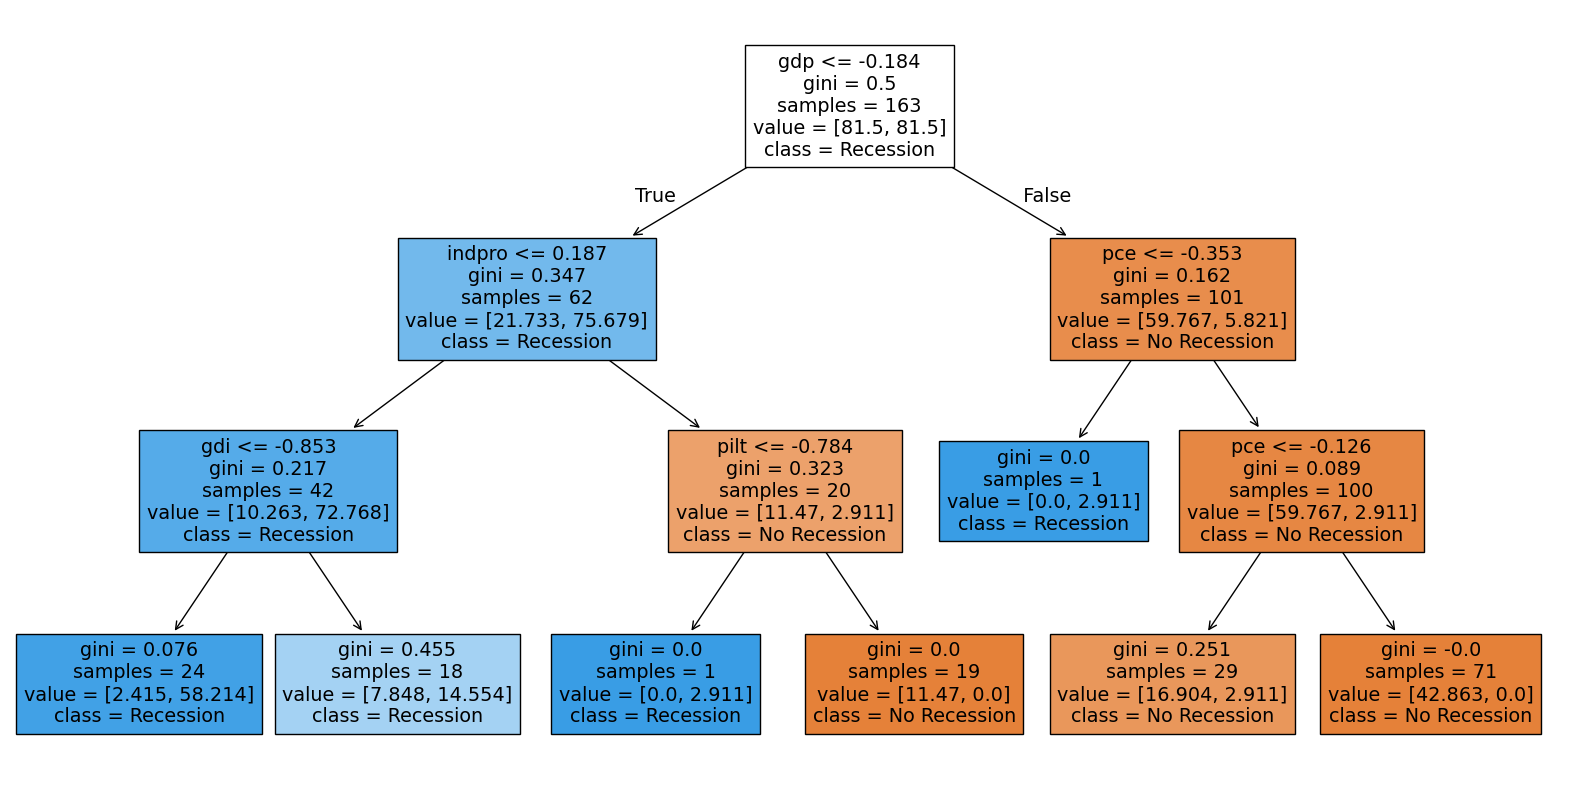

In [30]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dtc.best_estimator_, filled=True, feature_names=x_train.columns, class_names=['No Recession', 'Recession'])
plt.show()

#### Random Forest

In [31]:
rfc = GridSearchCV(RandomForestClassifier(max_features='sqrt', class_weight='balanced', random_state=42),
                   param_grid={
                       'n_estimators':[50, 100, 200],
                       'max_depth':[1, 3, 5, 7],
                       'min_samples_leaf':[1, 2, 4]},
                   cv=cv,
                   scoring='f1',
                   n_jobs=-1)
rfc.fit(x_train_scaled, y_train)
y_pred_rfc = rfc.predict(x_test_scaled)

print("Best Parameters:", rfc.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rfc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfc))

Best Parameters: RandomForestClassifier(class_weight='balanced', max_depth=3, n_estimators=50,
                       random_state=42)

Confusion Matrix:
[[57  5]
 [ 1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        62
           1       0.62      0.89      0.73         9

    accuracy                           0.92        71
   macro avg       0.80      0.90      0.84        71
weighted avg       0.94      0.92      0.92        71



#### Gradient Boosted Tree



Note that GBC doesn't natively support balancing the classes.

In [32]:
gbc = GridSearchCV(GradientBoostingClassifier(max_features='sqrt', random_state=42),
                   param_grid={
                       'n_estimators':[50, 100, 200],
                       'max_depth':[1, 3, 5, 7],
                       'min_samples_leaf':[1, 2, 4],
                       'learning_rate': [0.01, 0.1],
                       'subsample': [0.5, 0.8, 1.0]},
                   cv=cv,
                   scoring='f1',
                   n_jobs=-1)
gbc.fit(x_train_scaled, y_train)
y_pred_gbc = gbc.predict(x_test_scaled)

print("Best Parameters:", gbc.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gbc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gbc))

Best Parameters: GradientBoostingClassifier(max_features='sqrt', min_samples_leaf=4,
                           n_estimators=50, random_state=42, subsample=0.5)

Confusion Matrix:
[[61  1]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        62
           1       0.88      0.78      0.82         9

    accuracy                           0.96        71
   macro avg       0.92      0.88      0.90        71
weighted avg       0.96      0.96      0.96        71



#### XGBoost

In [33]:
# Need to set the ratio of classes manually, rather than using balanced class weights
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgbc = GridSearchCV(XGBClassifier(max_features='sqrt', scale_pos_weight=ratio, random_state=42),
                   param_grid={
                       'n_estimators':[50, 100, 200],
                       'max_depth':[1, 3, 5, 7],
                       'min_samples_leaf':[1, 2, 4],
                       'learning_rate': [0.01, 0.1],
                       'subsample': [0.5, 0.8, 1.0]},
                   cv=cv,
                   scoring='f1',
                   n_jobs=-1)
xgbc.fit(x_train_scaled, y_train)
y_pred_xgbc = xgbc.predict(x_test_scaled)

#print("Best Parameters:", xgbc.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgbc))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgbc))


Confusion Matrix:
[[55  7]
 [ 1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93        62
           1       0.53      0.89      0.67         9

    accuracy                           0.89        71
   macro avg       0.76      0.89      0.80        71
weighted avg       0.93      0.89      0.90        71



### Model 3: Support Vector Machine

In [34]:
from sklearn.svm import SVC

In [35]:
svml = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                    param_grid={
                        'kernel':['linear'],
                        'C':[0.01, 0.1, 10, 100, 1000]},
                    cv=cv,
                    scoring='f1',
                    n_jobs=-1)
svml.fit(x_train_scaled, y_train)
y_pred_svml = svml.predict(x_test_scaled)

print("Best Parameters:", svml.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svml))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svml))

Best Parameters: SVC(C=100, class_weight='balanced', kernel='linear', random_state=42)

Confusion Matrix:
[[47 15]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85        62
           1       0.32      0.78      0.45         9

    accuracy                           0.76        71
   macro avg       0.64      0.77      0.65        71
weighted avg       0.88      0.76      0.80        71



In [36]:
svmr = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                    param_grid={
                        'kernel':['rbf'],
                        'C':[0.01, 0.1, 10, 100, 1000]},
                    cv=cv,
                    scoring='f1',
                    n_jobs=-1)
svmr.fit(x_train_scaled, y_train)
y_pred_svmr = svmr.predict(x_test_scaled)

print("Best Parameters:", svmr.best_estimator_)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svmr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svmr))

Best Parameters: SVC(C=10, class_weight='balanced', random_state=42)

Confusion Matrix:
[[50 12]
 [ 3  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87        62
           1       0.33      0.67      0.44         9

    accuracy                           0.79        71
   macro avg       0.64      0.74      0.66        71
weighted avg       0.87      0.79      0.82        71



### Model 4: Neural Networks

#### Vanilla NN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, LayerNormalization, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
#np.isnan(x_train_scaled).sum()

In [39]:
nn = Sequential()

# Layer 1
nn.add(Dense(16, activation='relu', input_dim=x_train_scaled.shape[1]))
nn.add(Dropout(0.2))

# Layer 2
nn.add(Dense(8, activation='relu'))
nn.add(Dropout(0.2))

# Output Layer
nn.add(Dense(1, activation='sigmoid'))

nn.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_nn = nn.fit(x_train_scaled, y_train, epochs=200, batch_size=16, validation_split=0.2, callbacks=[early_stop])
y_pred_nn = nn.predict(x_test_scaled)

Epoch 1/200
9/9 [==============================] - 2s 54ms/step - loss: 0.6057 - accuracy: 0.7000 - val_loss: 0.6564 - val_accuracy: 0.5455
Epoch 2/200
9/9 [==============================] - 0s 7ms/step - loss: 0.5652 - accuracy: 0.7308 - val_loss: 0.6429 - val_accuracy: 0.6061
Epoch 3/200
9/9 [==============================] - 0s 7ms/step - loss: 0.5413 - accuracy: 0.7615 - val_loss: 0.6308 - val_accuracy: 0.6364
Epoch 4/200
9/9 [==============================] - 0s 7ms/step - loss: 0.5806 - accuracy: 0.7308 - val_loss: 0.6169 - val_accuracy: 0.6667
Epoch 5/200
9/9 [==============================] - 0s 7ms/step - loss: 0.5236 - accuracy: 0.8077 - val_loss: 0.6053 - val_accuracy: 0.6970
Epoch 6/200
9/9 [==============================] - 0s 7ms/step - loss: 0.5100 - accuracy: 0.7846 - val_loss: 0.5902 - val_accuracy: 0.7273
Epoch 7/200
9/9 [==============================] - 0s 8ms/step - loss: 0.4882 - accuracy: 0.7846 - val_loss: 0.5743 - val_accuracy: 0.7273
Epoch 8/200
9/9 [=========

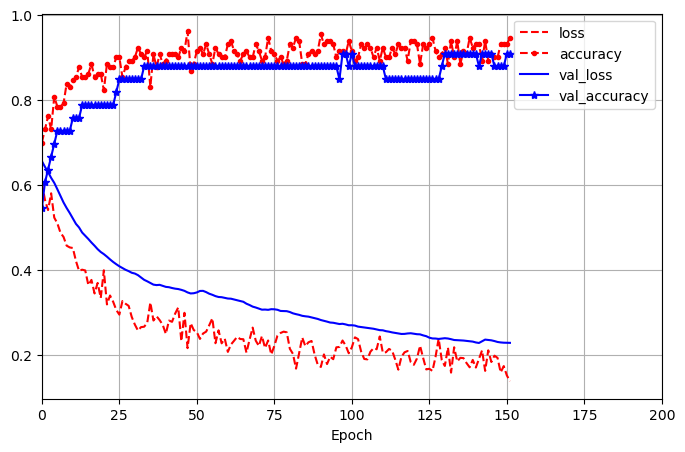

In [40]:
pd.DataFrame(history_nn.history).plot(
    figsize=(8, 5), xlim=[0, 200], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [41]:
y_pred_nn_classes = (y_pred_nn > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn_classes))


Confusion Matrix:
[[59  3]
 [ 2  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        62
           1       0.70      0.78      0.74         9

    accuracy                           0.93        71
   macro avg       0.83      0.86      0.85        71
weighted avg       0.93      0.93      0.93        71



#### RNN

In [42]:
# From Professor Liu:

def split_sequences(sequence, n_timesteps):
    
    X, y = [], []
    for i in range(len(sequence)):
        
        end_ind = i + n_timesteps
        
        if end_ind > len(sequence):
            break
        
        X_seq = sequence[i:end_ind, :-1]
        y_seq = sequence[end_ind-1, -1]
        
        X.append(X_seq)
        y.append(y_seq)
    
    return np.array(X),np.array(y)

In [43]:
x_scaled = pd.concat([x_train_scaled, x_test_scaled])

dataset = pd.concat([x_scaled, y], axis=1)
L=4 #Look back 1 year  (4qs)
# Create sequences on full dataset
x_all, y_all = split_sequences(dataset.values, L)

# Aligned index — each sample corresponds to the LAST row of its window
aligned_index = dataset.index[L - 1:]

# Split using same boolean condition as before
split_idx = np.sum(aligned_index < cutoff)

x_train2, y_train2 = x_all[:split_idx], y_all[:split_idx]
x_test2,  y_test2  = x_all[split_idx:], y_all[split_idx:]

print(f'Train: X={x_train2.shape}, y={y_train2.shape}')
print(f'Test:  X={x_test2.shape},  y={y_test2.shape}')

Train: X=(160, 4, 8), y=(160,)
Test:  X=(71, 4, 8),  y=(71,)


In [44]:
from tensorflow.keras.regularizers import l2

rnn = Sequential()
rnn.add(SimpleRNN(8, 
                  activation='tanh', 
                  input_shape=[x_train2.shape[1], x_train2.shape[2]], 
                  dropout=0.2, 
                  recurrent_dropout=0.2, 
                  kernel_regularizer = l2(0.01), 
                  return_sequences=False))
rnn.add(Dense(1, activation='sigmoid'))

rnn.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history_rnn = rnn.fit(x_train2, y_train2, epochs=200, batch_size=16, validation_split=0.2, callbacks=[early_stop])
y_pred_rnn = rnn.predict(x_test2)

Epoch 1/200
8/8 [==============================] - 2s 43ms/step - loss: 0.8010 - accuracy: 0.5938 - val_loss: 0.8726 - val_accuracy: 0.5312
Epoch 2/200
8/8 [==============================] - 0s 6ms/step - loss: 0.7289 - accuracy: 0.6562 - val_loss: 0.8652 - val_accuracy: 0.5625
Epoch 3/200
8/8 [==============================] - 0s 5ms/step - loss: 0.6862 - accuracy: 0.7109 - val_loss: 0.8564 - val_accuracy: 0.5625
Epoch 4/200
8/8 [==============================] - 0s 5ms/step - loss: 0.6611 - accuracy: 0.7422 - val_loss: 0.8488 - val_accuracy: 0.5625
Epoch 5/200
8/8 [==============================] - 0s 5ms/step - loss: 0.6992 - accuracy: 0.7266 - val_loss: 0.8411 - val_accuracy: 0.6250
Epoch 6/200
8/8 [==============================] - 0s 5ms/step - loss: 0.6006 - accuracy: 0.7969 - val_loss: 0.8330 - val_accuracy: 0.6250
Epoch 7/200
8/8 [==============================] - 0s 5ms/step - loss: 0.6520 - accuracy: 0.7344 - val_loss: 0.8242 - val_accuracy: 0.6250
Epoch 8/200
8/8 [=========

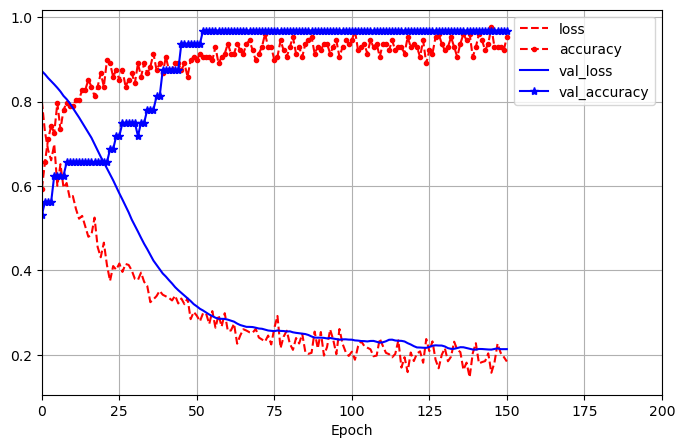

In [45]:
pd.DataFrame(history_rnn.history).plot(
    figsize=(8, 5), xlim=[0, 200], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [46]:
y_pred_rnn_classes = (y_pred_rnn > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rnn_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rnn_classes))


Confusion Matrix:
[[59  3]
 [ 1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        62
           1       0.73      0.89      0.80         9

    accuracy                           0.94        71
   macro avg       0.86      0.92      0.88        71
weighted avg       0.95      0.94      0.95        71



#### LSTM

In [47]:
lstm = Sequential()
lstm.add(LSTM(8, 
              activation='tanh', 
              input_shape=[x_train2.shape[1], x_train2.shape[2]], 
              dropout=0.2, 
              recurrent_dropout=0.2, 
              kernel_regularizer = l2(0.01), 
              return_sequences=False))
lstm.add(Dense(1, activation='sigmoid'))

lstm.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = lstm.fit(x_train2, y_train2, epochs=200, batch_size=16, validation_split=0.2, callbacks=[early_stop])
y_pred_lstm = lstm.predict(x_test2)

Epoch 1/200
8/8 [==============================] - 3s 53ms/step - loss: 0.7694 - accuracy: 0.7734 - val_loss: 0.8242 - val_accuracy: 0.5938
Epoch 2/200
8/8 [==============================] - 0s 7ms/step - loss: 0.7495 - accuracy: 0.8047 - val_loss: 0.8117 - val_accuracy: 0.6250
Epoch 3/200
8/8 [==============================] - 0s 7ms/step - loss: 0.7348 - accuracy: 0.8203 - val_loss: 0.7993 - val_accuracy: 0.6250
Epoch 4/200
8/8 [==============================] - 0s 7ms/step - loss: 0.7114 - accuracy: 0.7969 - val_loss: 0.7874 - val_accuracy: 0.5938
Epoch 5/200
8/8 [==============================] - 0s 6ms/step - loss: 0.6905 - accuracy: 0.8281 - val_loss: 0.7752 - val_accuracy: 0.6250
Epoch 6/200
8/8 [==============================] - 0s 6ms/step - loss: 0.6683 - accuracy: 0.8359 - val_loss: 0.7631 - val_accuracy: 0.6875
Epoch 7/200
8/8 [==============================] - 0s 6ms/step - loss: 0.6556 - accuracy: 0.8281 - val_loss: 0.7514 - val_accuracy: 0.6875
Epoch 8/200
8/8 [=========

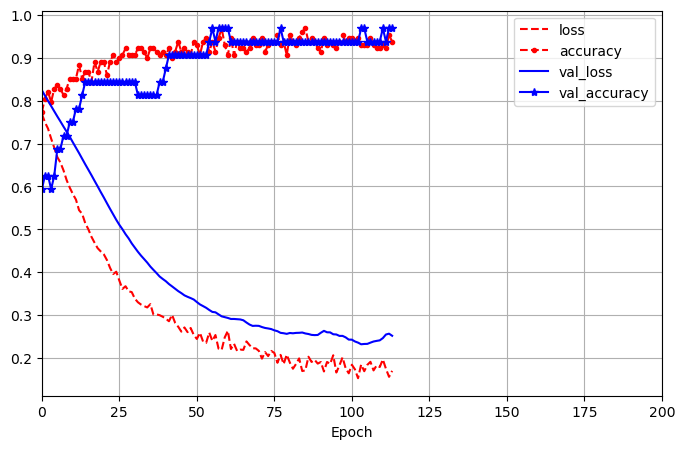

In [48]:
pd.DataFrame(history_lstm.history).plot(
    figsize=(8, 5), xlim=[0, 200], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [49]:
y_pred_lstm_classes = (y_pred_lstm > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lstm_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm_classes))


Confusion Matrix:
[[59  3]
 [ 1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97        62
           1       0.73      0.89      0.80         9

    accuracy                           0.94        71
   macro avg       0.86      0.92      0.88        71
weighted avg       0.95      0.94      0.95        71



#### GRU

In [50]:
gru = Sequential()
gru.add(GRU(8, 
            activation='tanh', 
            input_shape=[x_train2.shape[1], x_train2.shape[2]], 
            dropout=0.2, 
            recurrent_dropout=0.2, 
            kernel_regularizer = l2(0.01), 
            return_sequences=False))
gru.add(Dense(1, activation='sigmoid'))

gru.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history_gru = gru.fit(x_train2, y_train2, epochs=200, batch_size=16, validation_split=0.2, callbacks=[early_stop])
y_pred_gru = gru.predict(x_test2)

Epoch 1/200
8/8 [==============================] - 2s 56ms/step - loss: 0.7956 - accuracy: 0.6094 - val_loss: 0.8480 - val_accuracy: 0.5312
Epoch 2/200
8/8 [==============================] - 0s 5ms/step - loss: 0.7497 - accuracy: 0.7109 - val_loss: 0.8271 - val_accuracy: 0.5312
Epoch 3/200
8/8 [==============================] - 0s 5ms/step - loss: 0.7242 - accuracy: 0.7344 - val_loss: 0.8065 - val_accuracy: 0.5625
Epoch 4/200
8/8 [==============================] - 0s 5ms/step - loss: 0.6883 - accuracy: 0.8047 - val_loss: 0.7881 - val_accuracy: 0.6250
Epoch 5/200
8/8 [==============================] - 0s 6ms/step - loss: 0.6444 - accuracy: 0.8516 - val_loss: 0.7694 - val_accuracy: 0.5938
Epoch 6/200
8/8 [==============================] - 0s 7ms/step - loss: 0.6161 - accuracy: 0.8672 - val_loss: 0.7508 - val_accuracy: 0.6250
Epoch 7/200
8/8 [==============================] - 0s 6ms/step - loss: 0.5884 - accuracy: 0.8516 - val_loss: 0.7332 - val_accuracy: 0.6250
Epoch 8/200
8/8 [=========

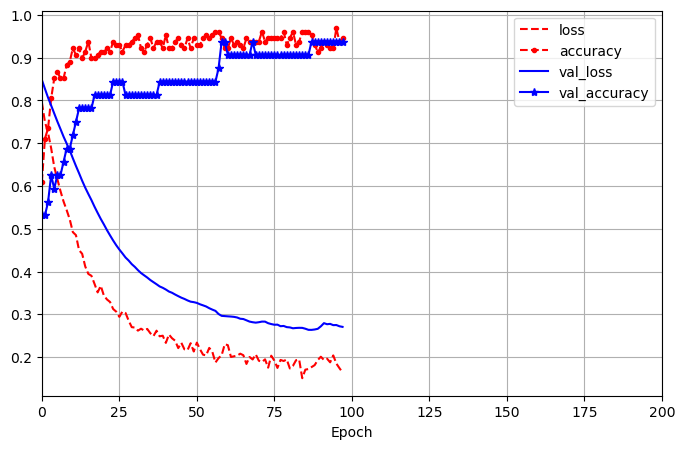

In [51]:
pd.DataFrame(history_gru.history).plot(
    figsize=(8, 5), xlim=[0, 200], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.show()

In [52]:
y_pred_gru_classes = (y_pred_gru > 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gru_classes))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gru_classes))


Confusion Matrix:
[[61  1]
 [ 1  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        62
           1       0.89      0.89      0.89         9

    accuracy                           0.97        71
   macro avg       0.94      0.94      0.94        71
weighted avg       0.97      0.97      0.97        71



### Formatting Results

In [53]:
test_dates = x_test.index
results = pd.DataFrame(index=test_dates)

results['Actual'] = y_test
results['CP2008'] = y_pred_ms_classes
results['LogReg'] = y_pred_log
results['Ridge'] = y_pred_ridge
results['Lasso'] = y_pred_lasso
results['ElasticNet'] = y_pred_enet
results['ClassTree'] = y_pred_dtc
results['RandomForest'] = y_pred_rfc
results['GradientBoost'] = y_pred_gbc
results['XGBoost'] = y_pred_xgbc
results['SVM-L'] = y_pred_svml
results['SVM-R'] = y_pred_svmr
results['NN'] = y_pred_nn_classes.flatten()
results['RNN'] = y_pred_rnn_classes.flatten()
results['LSTM'] = y_pred_lstm_classes.flatten()
results['GRU'] = y_pred_gru_classes.flatten()

print(results.tail(16))

            Actual  CP2008  LogReg  Ridge  Lasso  ElasticNet  ClassTree  \
date                                                                      
2021-10-01       0       0       0      0      0           0          0   
2022-01-01       0       0       0      0      0           0          0   
2022-04-01       0       0       1      1      1           1          1   
2022-07-01       0       0       0      0      0           0          0   
2022-10-01       0       0       0      0      0           0          0   
2023-01-01       0       0       0      0      0           0          1   
2023-04-01       0       0       0      1      0           0          0   
2023-07-01       0       0       0      0      0           0          0   
2023-10-01       0       0       0      0      0           0          0   
2024-01-01       0       0       1      1      1           1          1   
2024-04-01       0       0       0      1      0           0          0   
2024-07-01       0       

In [55]:
results.to_excel('results.xlsx')

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = []

actual = results['Actual']

for column in results.columns:
    if column == 'Actual':
        continue

    pred = results[column]

    acc = round(accuracy_score(actual, pred), 4)
    prec = round(precision_score(actual, pred, zero_division=0), 4) #Crying wolf
    rec  = round(recall_score(actual, pred, zero_division=0), 4) #Asleep at wheel
    f1 = round(f1_score(actual, pred), 4)

    metrics.append({'Model':column, 'Accuracy':acc, 'Precision':prec, 'Recall':rec, 'F1 Score':f1})
metrics.append({'Model':'Null', 
                'Accuracy':accuracy_score(actual, y_pred_null), 
                'F1 Score':accuracy_score(actual, y_pred_null)})

performance = pd.DataFrame(metrics)
performance.set_index('Model', inplace=True)
performance = performance.sort_values(by='F1 Score', ascending=False)
print(performance)

               Accuracy  Precision  Recall  F1 Score
Model                                               
GRU            0.971800     0.8889  0.8889  0.888900
Null           0.873239        NaN     NaN  0.873239
GradientBoost  0.957700     0.8750  0.7778  0.823500
RNN            0.943700     0.7273  0.8889  0.800000
LSTM           0.943700     0.7273  0.8889  0.800000
NN             0.929600     0.7000  0.7778  0.736800
RandomForest   0.915500     0.6154  0.8889  0.727300
XGBoost        0.887300     0.5333  0.8889  0.666700
CP2008         0.901400     0.6250  0.5556  0.588200
LogReg         0.802800     0.3684  0.7778  0.500000
Ridge          0.774600     0.3478  0.8889  0.500000
Lasso          0.788700     0.3500  0.7778  0.482800
ElasticNet     0.788700     0.3500  0.7778  0.482800
SVM-L          0.760600     0.3182  0.7778  0.451600
SVM-R          0.788700     0.3333  0.6667  0.444400
ClassTree      0.732400     0.2917  0.7778  0.424200


In [59]:
performance.to_excel('performance.xlsx')

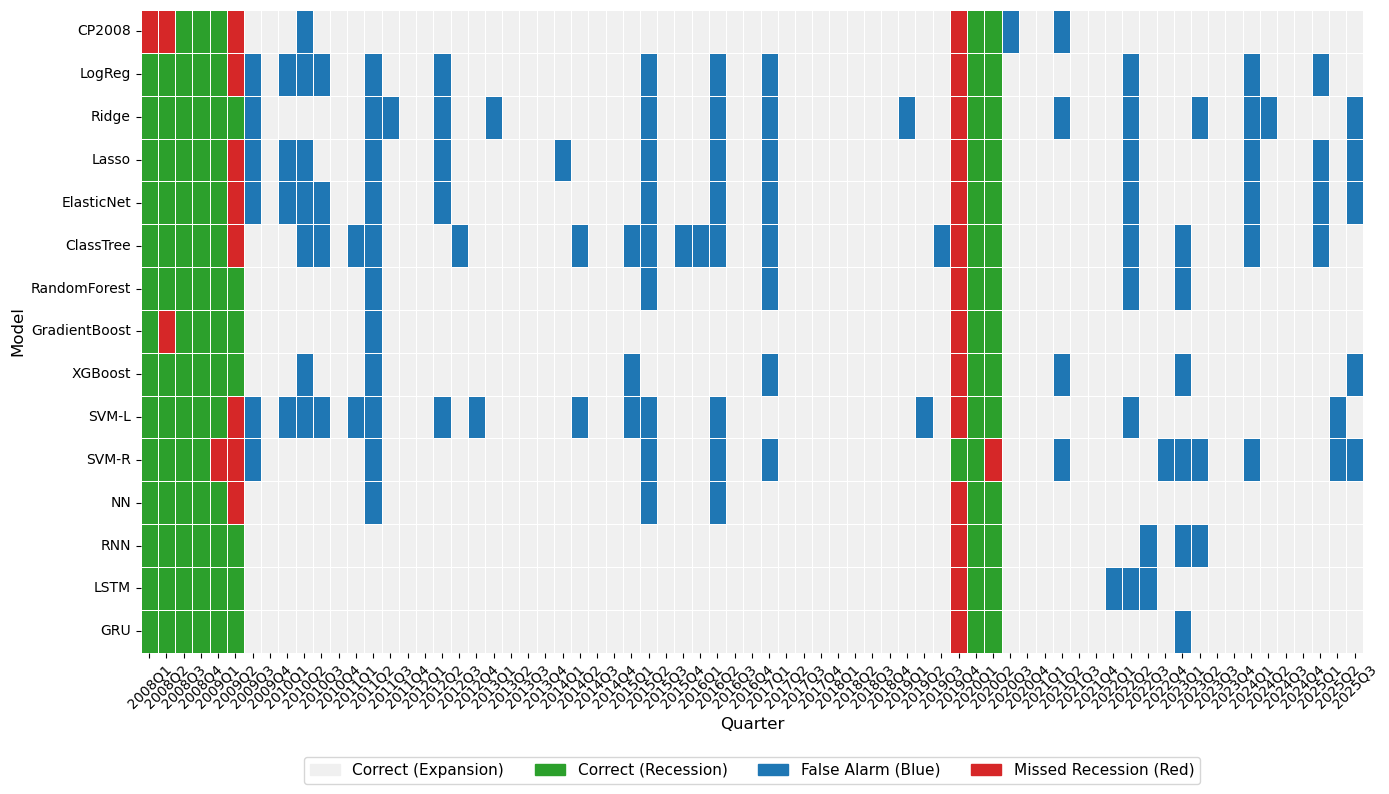

In [62]:
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

models = results.columns.drop('Actual') # Keep all columns except the ground truth
heatmap_data = pd.DataFrame(index=results.index.to_period('Q').astype(str), columns=models)

for model in models:
    # True Negative (Correct Expansion) -> 0
    heatmap_data.loc[(results['Actual'] == 0) & (results[model] == 0), model] = 0
    
    # True Positive (Correct Recession) -> 1
    heatmap_data.loc[(results['Actual'] == 1) & (results[model] == 1), model] = 1
    
    # False Positive (False Alarm / Blue) -> 2
    heatmap_data.loc[(results['Actual'] == 0) & (results[model] == 1), model] = 2
    
    # False Negative (Missed Recession / Red) -> 3
    heatmap_data.loc[(results['Actual'] == 1) & (results[model] == 0), model] = 3

heatmap_data = heatmap_data.astype(float)


cmap = ListedColormap(['#f0f0f0', '#2ca02c', '#1f77b4', '#d62728'])

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data.T, cmap=cmap, cbar=False, linewidths=0.5, linecolor='white')

plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Model", fontsize=12)

tn_patch = mpatches.Patch(color='#f0f0f0', label='Correct (Expansion)')
tp_patch = mpatches.Patch(color='#2ca02c', label='Correct (Recession)')
fp_patch = mpatches.Patch(color='#1f77b4', label='False Alarm (Blue)')
fn_patch = mpatches.Patch(color='#d62728', label='Missed Recession (Red)')

plt.legend(handles=[tn_patch, tp_patch, fp_patch, fn_patch], 
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()